In [1]:
import time
import numpy as np

In [2]:
import pyvisa
TEK_VID_PID="0x0699::0x0365"

rc = pyvisa.ResourceManager()

for r in rc.list_resources_info():
    if TEK_VID_PID in r:
        scope = rc.open_resource(r)

In [129]:
import re

class _Channel:
    def __init__(self, parent, idx):
        parent._chk_ch(idx)
        self._p = parent
        self._i = idx

    @property
    def scale(self) -> float:  # V/div
        return self._p._qnum(f"CH{self._i}:SCALE?")

    @scale.setter
    def scale(self, val: float):
        self._p.io.write(f"CH{self._i}:SCALE {val}")

    @property
    def position(self) -> float:  # divisions
        return self._p._qnum(f"CH{self._i}:POSITION?")

    @position.setter
    def position(self, val: float):
        self._p.io.write(f"CH{self._i}:POSITION {val}")


class _Trigger:
    def __init__(self, parent):
        self._p = parent

    @property
    def source(self) -> str:
        # CH1..CH4, EXT, EXT5 (if present), LINE
        return self._p.io.query("TRIGGER:MAIN:EDGE:SOURCE?").strip()

    @source.setter
    def source(self, val: str):
        val = val.upper()
        allowed = {f"CH{i}" for i in range(1,5)} | {"EXT", "LINE"}
        if val not in allowed:
            raise ValueError(f"source must be one of {sorted(allowed)}")
        self._p.io.write(f"TRIGGER:MAIN:EDGE:SOURCE {val}")

    @property
    def level(self) -> float:
        return self._p.io.query("TRIGGER:MAIN:LEVEL?").strip()

    @level.setter
    def level(self, val):
        self._p.io.write(f"TRIGGER:MAIN:LEVEL {val}")
    
    @property
    def mode(self) -> str:
        # AUTO or NORMal
        return self._p.io.query("TRIGGER:MAIN:MODE?").strip()

    @mode.setter
    def mode(self, val: str):
        val = val.upper()
        if val in ("NORMAL", "NORM"):
            val = "NORMal"
        elif val == "AUTO":
            val = "AUTO"
        else:
            raise ValueError("mode must be 'AUTO' or 'NORMal'")
        self._p.io.write(f"TRIGGER:MAIN:MODE {val}")

    def force(self):
        """Force a trigger event (does not start acquisition if stopped)."""
        self._p.io.write("TRIGGER:FORCE")

class _Acquire:
    def __init__(self, parent):
        self._p = parent
        
    # ACQUIRE:STATE?  -> '0' or '1'
    @property
    def state(self) -> bool:
        return bool(int(self._p.io.query("ACQUIRE:STATE?").strip()))

    @state.setter
    def state(self, running: bool):
        self._p.io.write(f"ACQUIRE:STATE {'RUN' if running else 'STOP'}")

    def stop(self):
        self._p.io.write("ACQUIRE:STATE STOP")

    def run(self):
        self._p.io.write("ACQUIRE:STATE RUN")

    # ACQUIRE:STOPAFTER? / ACQUIRE:STOPAFTER SEQ|RUNSTOP
    @property
    def stopafter(self) -> str:
        return self._p.io.query("ACQUIRE:STOPAFTER?").strip().upper()

    @stopafter.setter
    def stopafter(self, mode: str):
        m = mode.strip().upper()
        if m in ("SEQ", "SEQUENCE"):
            m = "SEQUENCE"
        elif m in ("RUNSTOP", "RUN/STOP"):
            m = "RUNSTOP"
        else:
            raise ValueError("stopafter must be SEQUENCE or RUNSTOP")
        self._p.io.write(f"ACQUIRE:STOPAFTER {m}")

    def arm_single(self):
        """Equivalent to:
           ACQUIRE:STATE STOP
           ACQUIRE:STOPAFTER SEQ
           ACQUIRE:STATE RUN
        """
        self.stop()
        self.stopafter = "SEQUENCE"
        self.run()

    def wait_until_stopped(self, timeout_s: float = 5.0, poll_s: float = 0.05) -> bool:
        """
        Block until ACQUIRE:STATE? == 0 (stopped) or timeout.
        Returns True if stopped, False on timeout.
        """
        deadline = time.time() + timeout_s
        while time.time() < deadline:
            if not self.state:
                return True
            time.sleep(poll_s)
        return False
        
    @property
    def state(self) -> bool:
        # True=running, False=stopped
        return bool(int(self._p.io.query("ACQUIRE:STATE?").strip()))

    @state.setter
    def state(self, running: bool):
        self._p.io.write(f"ACQUIRE:STATE {'RUN' if running else 'STOP'}")

    def run(self):
        self.state = True

    def stop(self):
        self.state = False

    def single(self, wait: bool = True, timeout_s: float = 3.0):
        """
        Arm single-sequence acquisition and (optionally) wait until done.
        """
        self._p.io.write("ACQUIRE:STOPAFTER SEQUENCE")
        # Clear event status and set *OPC to signal completion
        self._p.io.write("*CLS")
        self._p.io.write("ACQUIRE:STATE RUN")
        if wait:
            old_to = self._p.io.timeout
            try:
                # pyvisa timeout is in ms
                self._p.io.timeout = int(max(timeout_s, 0.05) * 1000)
                # *OPC? blocks until acquisition complete
                self._p.io.query("*OPC?")
            finally:
                self._p.io.timeout = old_to
        # return to continuous stop-after (optional; comment out if you prefer SEQUENCE to persist)
        self._p.io.write("ACQUIRE:STOPAFTER RUNSTOP")


class TDS2004:
    def __init__(self, resource):
        """
        resource: an open pyvisa resource (e.g., from rc.open_resource(...))
        """
        self.io = resource
        # Tektronix usually wants \n line termination
        self.io.write_termination = '\n'
        self.io.read_termination  = '\n'
        self.ch = {i: _Channel(self, i) for i in range(1, 5)}
        self.trig = _Trigger(self)
        self.acq  = _Acquire(self)

    # --- helpers ---
    @staticmethod
    def _to_number(s: str) -> float:
        """
        Convert Tek 'engineering notation' strings to float.
        Accepts forms like '2.0E-3', '5m', '1.2 k', '10uV', '2.5 s', etc.
        """
        s = s.strip()
        # try plain float first (covers 1.23E-6, etc.)
        try:
            return float(s)
        except ValueError:
            pass

        # strip units/spaces, capture optional SI suffix
        m = re.fullmatch(r'\s*([+-]?[\d_]*\.?\d+(?:[eE][+-]?\d+)?)\s*([yzafpnumkKMGT]?)(?:[A-Za-z/]+)?\s*', s)
        if not m:
            raise ValueError(f"Cannot parse number: {s}")

        base, suffix = m.group(1), m.group(2)
        x = float(base)
        si = {
            'y': 1e-24, 'z': 1e-21, 'a': 1e-18, 'f': 1e-15, 'p': 1e-12,
            'n': 1e-9,  'u': 1e-6,  'm': 1e-3,  'k': 1e3,   'K': 1e3,
            'M': 1e6,   'G': 1e9,   'T': 1e12,  '': 1.0
        }
        return x * si.get(suffix, 1.0)

    def _qnum(self, cmd: str) -> float:
        return self._to_number(self.io.query(cmd))

    @staticmethod
    def _chk_ch(ch: int) -> int:
        if ch not in (1, 2, 3, 4):
            raise ValueError("Channel must be 1..4")
        return ch

    # --- vertical (per-channel) ---
    def get_vscale(self, ch: int) -> float:
        ch = self._chk_ch(ch)
        return self._qnum(f"CH{ch}:SCALE?")          # V/div

    def get_vpos(self, ch: int) -> float:
        ch = self._chk_ch(ch)
        return self._qnum(f"CH{ch}:POSITION?")       # divisions

    # --- horizontal (main) ---
    def get_hscale(self) -> float:
        return self._qnum("HORIZONTAL:MAIN:SCALE?")  # s/div

    def get_hpos(self) -> float:
        return self._qnum("HORIZONTAL:MAIN:POSITION?")  # divisions
    
    @property
    def hscale(self) -> float:  # s/div
        return self._qnum("HORIZONTAL:MAIN:SCALE?")
    
    @hscale.setter
    def hscale(self, val: float):
        self.io.write(f"HORIZONTAL:MAIN:SCALE {val}")
    
    @property
    def hpos(self) -> float:    # divisions
        return self._qnum("HORIZONTAL:MAIN:POSITION?")
    
    @hpos.setter
    def hpos(self, val: float):
        self.io.write(f"HORIZONTAL:MAIN:POSITION {val}")
        
    def _wfm_preamble(self):
        return {
            'YMULT': self._qnum("WFMPRE:YMULT?"),
            'YZERO': self._qnum("WFMPRE:YZERO?"),
            'YOFF':  self._qnum("WFMPRE:YOFF?"),
            'XINCR': self._qnum("WFMPRE:XINCR?"),
            'XZERO': self._qnum("WFMPRE:XZERO?"),
            'NR_PT': int(self.io.query("WFMPRE:NR_PT?")),
        }
    
    def read_curve(self, ch: int, start: int = None, stop: int = None, width: int = 2):
        """
        Fetch waveform from CHx, scale to seconds/volts, return (t, y).
        width: 1 or 2 bytes per sample. 2 recommended for TDS2000 series.
        """
        ch = self._chk_ch(ch)
        self.io.write(f"DATA:SOURCE CH{ch}")
        self.io.write("DATA:ENCDG RIBINARY")
        tek.io.write("WFMPre:BYT_Or LSB")
        self.io.write(f"DATA:WIDTH {int(width)}") # 1 or 2
        pre = self._wfm_preamble()
    
        n = pre['NR_PT']
        if start is None: start = 1
        if stop  is None: stop  = n
        self.io.write(f"DATA:START {start}")
        self.io.write(f"DATA:STOP {stop}")
    
        # Choose PyVISA datatype matching DATA:WIDTH and signed RIBINARY
        dtype = 'h' if width == 2 else 'b'      # signed 16-bit or 8-bit
        raw = self.io.query_binary_values("CURVE?", datatype=dtype, container=np.array)
    
        # Scale to engineering units
        y = (raw - pre['YOFF']) * pre['YMULT'] + pre['YZERO']
        t0 = pre['XZERO'] + (start - 1) * pre['XINCR']
        t = t0 + np.arange(raw.size) * pre['XINCR']
        return t, y



In [131]:
tek = TDS2004(scope)

In [133]:
tek.io.query("DATA:ENCDG?")

'SRI'

In [135]:
p = tek._wfm_preamble()
p

{'YMULT': 0.0003125,
 'YZERO': 0.0,
 'YOFF': -14848.0,
 'XINCR': 2e-05,
 'XZERO': -0.0154,
 'NR_PT': 2500}

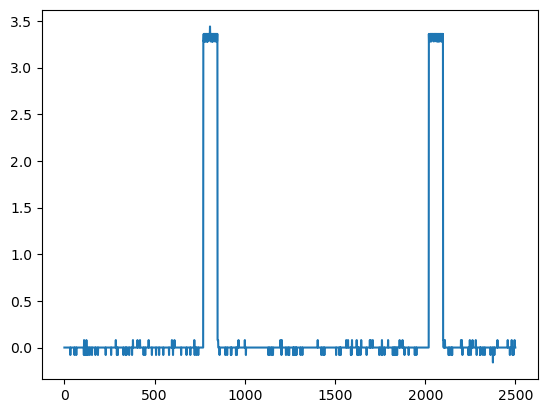

In [137]:
raw = tek.io.query_binary_values("CURVE?", datatype='h', container=np.array)
k = p['YMULT']
y0 = p['YZERO']
yoff = p['YOFF']
plt.plot((raw - yoff)*k + y0);plt.show()

In [139]:
t, y = tek.read_curve(1)

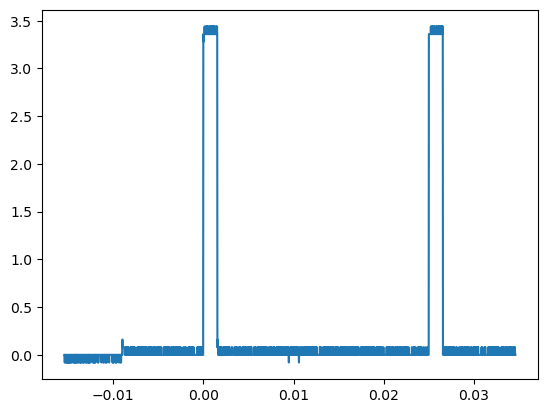

In [159]:
tek.trig.source = 'CH1'
tek.trig.level = 2.0
tek.trig.mode = 'NORM'
tek.acq.stopafter = 'SEQ'
tek.acq.run()
tek.acq.wait_until_stopped()
plt.plot(*tek.read_curve(1)); plt.show()

In [224]:
tek.ch[1].scale = 2
tek.hscale = 0.005

In [23]:
from matplotlib import pyplot as plt
%matplotlib inline

In [226]:
tek.trig.source = 'CH1'

In [228]:
tek.trig.level = 1.8

In [230]:
tek.trig.mode = 'NORM'

In [256]:
tek.acq.stopafter = 'SEQ'

In [258]:
tek.acq.run()
tek.acq.wait_until_stopped()

True

In [214]:
tek.io.write("ACQUIRE:STOPAF SEQ")

19

In [208]:
tek.io.write("ACQUIRE:STATE RUN")

18

In [216]:
tek.io.query("ACQUIRE:STATE?")

'0'